In [1]:
# Walmart Sales · разные масштабы, MAPE незаменим

#**Контекст:** предсказываем недельные продажи магазинов Walmart по 7 признакам
#(температура, цена топлива, CPI, безработица, год/месяц, флаг праздника).

#**Особенность данных:** продажи разных магазинов отличаются в 5–10 раз.
#Один магазин может продавать $1.5M в неделю, другой — $0.3M.

#**Целевые метрики:** MAPE (процент ошибки), а не MAE.

#**Почему:**
#- MAE = $50,000 звучит одинаково плохо для всех магазинов.
#- Но для магазина с продажами $1.5M это 3% ошибки — прекрасно.
#- А для магазина с $0.3M это 17% — уже плохо.
#- **MAE в долларах скрывает эту разницу. MAPE её показывает.**

#**Что показываем:**
#- MAE в долларах растёт с размером магазина — но MAPE стабилен.
#- RMSE/MAE ≈ 1.3 — ошибки не катастрофические.
#- Bias ≈ 0 — модель не смещена.
#- **Метрика-герой: MAPE.** Именно она усредняет качество между магазинами правильно.

#**Главный вывод:** метрика выбирается по **структуре данных**, а не по удобству.
#Разный масштаб → MAPE. Одинаковый масштаб → MAE.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, median_absolute_error, max_error, explained_variance_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'walmart'

MODEL_DIR = PROJECT / 'models' / 'regression' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'regression' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/regression/walmart
ART_DIR  : /app/artifacts/regression/walmart


In [3]:
def reg_metrics(y_true, y_pred):
    """
    Все регрессионные метрики в один словарь.

    bias = mean(y_pred - y_true):
      bias > 0 → модель систематически ЗАВЫШАЕТ
      bias < 0 → модель систематически ЗАНИЖАЕТ

    rmsle — RMSE в логарифме (log1p). При разбросе продаж в разы
    честнее RMSE, т.к. штрафует относительную ошибку, а не абсолютную.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_pred - y_true
    return {
        'mae':       mean_absolute_error(y_true, y_pred),
        'rmse':      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'rmsle':     float(np.sqrt(np.mean(
            (np.log1p(np.maximum(y_pred, 0)) - np.log1p(np.maximum(y_true, 0))) ** 2
        ))),
        'mape':      mean_absolute_percentage_error(y_true, y_pred) * 100,
        'r2':        r2_score(y_true, y_pred),
        'medae':     median_absolute_error(y_true, y_pred),
        'bias':      float(np.mean(residuals)),
        'max_error': float(max_error(y_true, y_pred)),
        'evs':       explained_variance_score(y_true, y_pred),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    order = ['mae', 'rmse', 'rmsle', 'mape', 'r2', 'medae', 'bias', 'max_error', 'evs']
    return df[order].round(4)


def metrics_table_ru(results: dict) -> pd.DataFrame:
    return metrics_table(results).rename(columns={
        'mae':       'MAE',
        'rmse':      'RMSE',
        'rmsle':     'RMSLE',
        'mape':      'MAPE,%',
        'r2':        'R²',
        'medae':     'MedAE',
        'bias':      'Bias',
        'max_error': 'MaxErr',
        'evs':       'EVS',
    })


def money(v):
    """Форматирование долларов — компактное."""
    return f'${v/1e6:.2f}M' if abs(v) >= 1e6 else f'${v/1e3:.1f}k'

In [4]:
## 1. Загрузка данных

#Датасет `talhaanjum0/walmart-dataset` — реальные недельные данные Walmart
#за 2010–2012. Формат: одна CSV-таблица.

#**Признаки:**
#- `Store` — номер магазина (1–45)
#- `Date` — дата недели
#- `Weekly_Sales` — целевая (продажи за неделю, $)
#- `Holiday_Flag` — 1 если неделя праздничная, 0 иначе
#- `Temperature` — температура в регионе, °F
#- `Fuel_Price` — цена топлива, $
#- `CPI` — индекс потребительских цен
#- `Unemployment` — безработица, %

#**Задача:** предсказать `Weekly_Sales` по остальным признакам.
#Это **регрессия на табличных данных**, а не прогноз временного ряда
#(для прогноза нужны лаги — вынесем это в forecasting)

In [5]:
# Скачиваем датасет через kagglehub
csv_path = None
try:
    path = kagglehub.dataset_download('talhaanjum0/walmart-dataset')
    print('kagglehub downloaded →', path)
    candidates = list(Path(path).glob('*.csv'))
    for c in candidates:
        if 'walmart' in c.name.lower() or c.stat().st_size > 100_000:
            csv_path = c
            break
    if csv_path is None and candidates:
        csv_path = candidates[0]
except Exception as e:
    print('kagglehub недоступен:', e)

# Fallback: локальная копия
if csv_path is None or not Path(csv_path).exists():
    csv_path = PROJECT / 'data' / 'walmart' / 'Walmart.csv'
    print('использую локальный:', csv_path)

print('reading:', csv_path)
df = pd.read_csv(csv_path)
print()
print('shape:', df.shape)
print('columns:', list(df.columns))
df.head()

kagglehub downloaded → /root/.cache/kagglehub/datasets/talhaanjum0/walmart-dataset/versions/1
reading: /root/.cache/kagglehub/datasets/talhaanjum0/walmart-dataset/versions/1/Walmart.csv

shape: (6435, 8)
columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
# У разных версий датасета колонки называются по-разному.
# Приводим к единому виду.

rename_map = {
    'Weekly_Sales': 'Weekly_Sales',
    'weekly_sales': 'Weekly_Sales',
    'Holiday_Flag': 'Holiday_Flag',
    'holiday_flag': 'Holiday_Flag',
    'Temperature':  'Temperature',
    'Fuel_Price':   'Fuel_Price',
    'CPI':          'CPI',
    'Unemployment': 'Unemployment',
    'Store':        'Store',
    'Date':         'Date',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print('после переименования:', list(df.columns))
print()

# Дата: в датасете Walmart формат DD-MM-YYYY (dayfirst=True!)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    n_before = len(df)
    df = df.dropna(subset=['Date']).reset_index(drop=True)
    n_after = len(df)
    if n_before != n_after:
        print(f'Удалено строк с невалидной датой: {n_before - n_after}')
    else:
        print('Все даты распарсились успешно')

# Убираем строки с NaN в целевой
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print('shape после очистки:', df.shape)
print()
print(df.describe().round(2))

после переименования: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Все даты распарсились успешно
shape после очистки: (6435, 8)

         Store                 Date  Weekly_Sales  Holiday_Flag  Temperature  \
count  6435.00                 6435       6435.00       6435.00      6435.00   
mean     23.00  2011-06-17 00:00:00    1046964.88          0.07        60.66   
min       1.00  2010-02-05 00:00:00     209986.25          0.00        -2.06   
25%      12.00  2010-10-08 00:00:00     553350.10          0.00        47.46   
50%      23.00  2011-06-17 00:00:00     960746.04          0.00        62.67   
75%      34.00  2012-02-24 00:00:00    1420158.66          0.00        74.94   
max      45.00  2012-10-26 00:00:00    3818686.45          1.00       100.14   
std      12.99                  NaN     564366.62          0.26        18.44   

       Fuel_Price      CPI  Unemployment  
count     6435.00  6435.00       6435.00  
mean  

In [7]:
## 2. EDA — структура продаж

#Смотрим:
#- распределение `Weekly_Sales` — сразу видно, что оно **сильно право-скошено**;
#- распределение продаж **по магазинам** — видно, что разброс между магазинами в разы;
#- связь `Holiday_Flag` с продажами — праздники дают всплеск;
#- корреляцию остальных признаков с target.

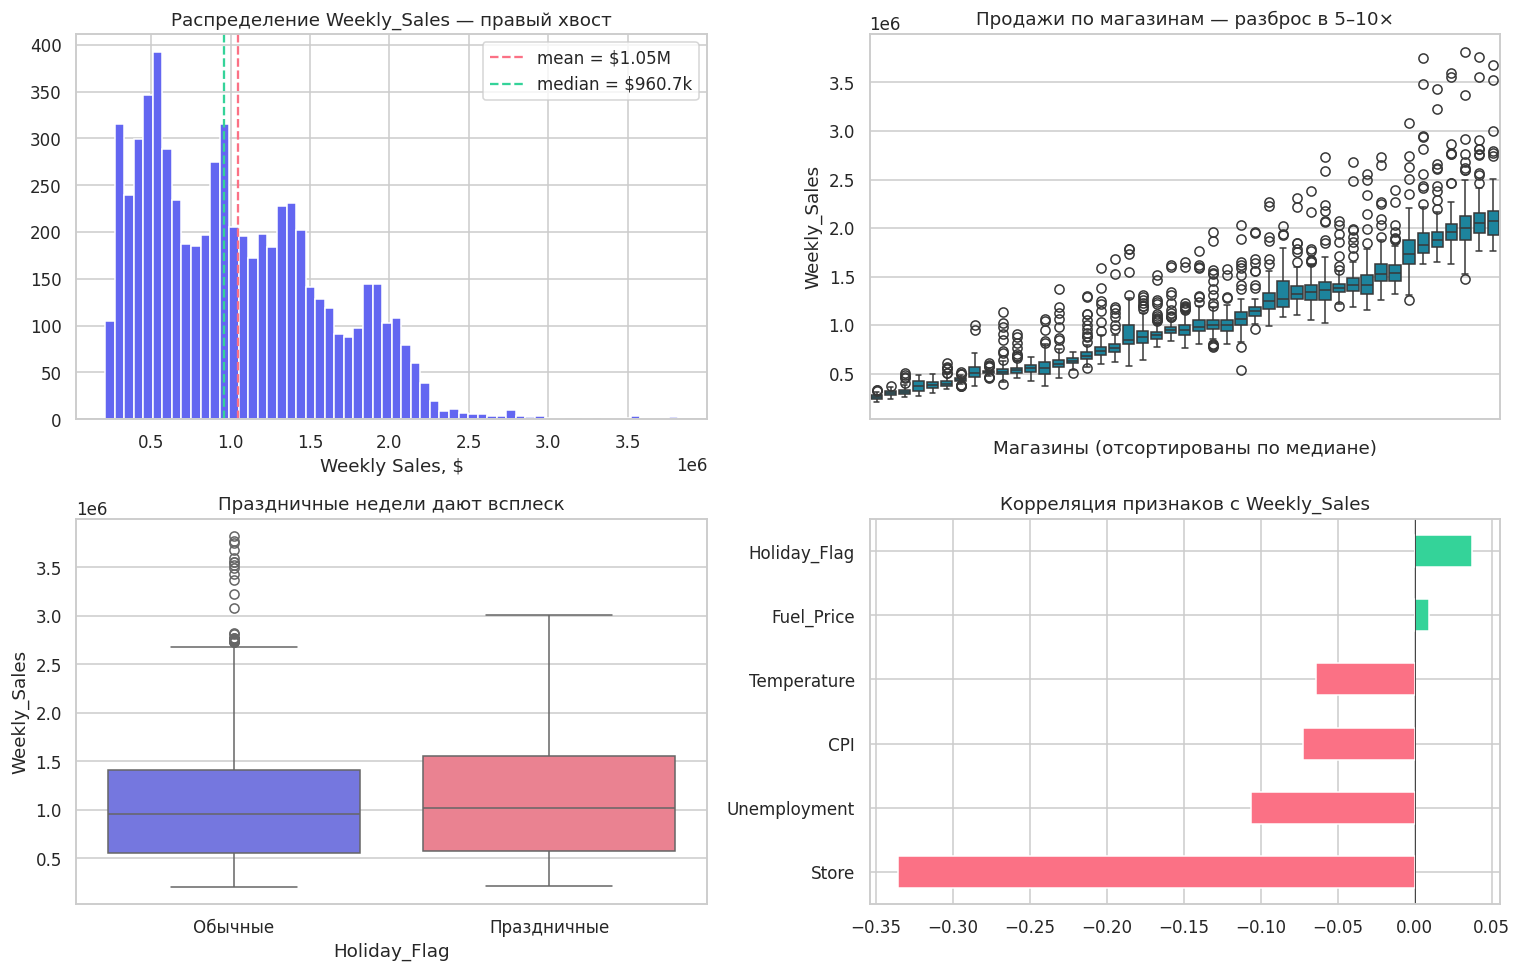

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 2.1 Гистограмма Weekly_Sales
axes[0, 0].hist(df['Weekly_Sales'], bins=60, color='#6366f1', edgecolor='white')
axes[0, 0].set_title('Распределение Weekly_Sales — правый хвост')
axes[0, 0].set_xlabel('Weekly Sales, $')
axes[0, 0].axvline(df['Weekly_Sales'].mean(), color='#fb7185', ls='--',
                   label=f'mean = {money(df["Weekly_Sales"].mean())}')
axes[0, 0].axvline(df['Weekly_Sales'].median(), color='#34d399', ls='--',
                   label=f'median = {money(df["Weekly_Sales"].median())}')
axes[0, 0].legend()

# 2.2 Box-plot продаж по магазинам — виден разброс масштабов
if 'Store' in df.columns:
    store_order = df.groupby('Store')['Weekly_Sales'].median().sort_values().index
    sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=store_order,
                ax=axes[0, 1], color='#0891b2')
    axes[0, 1].set_title('Продажи по магазинам — разброс в 5–10×')
    axes[0, 1].set_xticklabels([])
    axes[0, 1].set_xlabel('Магазины (отсортированы по медиане)')

# 2.3 Holiday Flag vs продажи
if 'Holiday_Flag' in df.columns:
    sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', ax=axes[1, 0],
                palette=['#6366f1', '#fb7185'])
    axes[1, 0].set_title('Праздничные недели дают всплеск')
    axes[1, 0].set_xticklabels(['Обычные', 'Праздничные'])

# 2.4 Корреляции
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Weekly_Sales' in num_cols:
    corrs = df[num_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values()
    corrs.plot(kind='barh', ax=axes[1, 1],
               color=['#fb7185' if v < 0 else '#34d399' for v in corrs])
    axes[1, 1].axvline(0, color='k', lw=0.5)
    axes[1, 1].set_title('Корреляция признаков с Weekly_Sales')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [9]:
## 3. Ключевое наблюдение: разный масштаб продаж

#Посмотрим статистику по магазинам: **median, min, max**.

#Если разброс медиан между магазинами большой (например, от $250k до $2M) — это
#и есть причина, по которой **MAE в долларах бесполезен**.

#Покажем это численно и потом — на графике.

In [10]:
if 'Store' in df.columns:
    store_stats = df.groupby('Store')['Weekly_Sales'].agg(['median', 'min', 'max', 'count'])
    store_stats.columns = ['median_sales', 'min_sales', 'max_sales', 'n_weeks']
    store_stats = store_stats.sort_values('median_sales')

    print('Сводка по 5 самым маленьким магазинам:')
    print(store_stats.head().round(0))
    print()
    print('Сводка по 5 самым большим:')
    print(store_stats.tail().round(0))
    print()
    ratio = store_stats['median_sales'].iloc[-1] / store_stats['median_sales'].iloc[0]
    print(f'Отношение самого большого к самому маленькому (по медиане): {ratio:.2f}×')
    print(f'Абсолютный диапазон медиан: {money(store_stats["median_sales"].iloc[0])} … '
          f'{money(store_stats["median_sales"].iloc[-1])}')
    print()
    print('Вывод: ошибка $50k для большого магазина = ~2–3%, для маленького = ~15–20%.')
    print('Значит, MAE в долларах некорректно усредняет качество между магазинами.')
else:
    print('Столбец Store не найден — пропускаем анализ по магазинам.')

Сводка по 5 самым маленьким магазинам:
       median_sales  min_sales  max_sales  n_weeks
Store                                             
33         258427.0   209986.0   331174.0      143
44         298080.0   241937.0   376234.0      143
5          310338.0   260637.0   507900.0      143
36         373268.0   270678.0   489372.0      143
38         380870.0   303909.0   499268.0      143

Сводка по 5 самым большим:
       median_sales  min_sales  max_sales  n_weeks
Store                                             
2         1879107.0  1650394.0  3436008.0      143
13        1958824.0  1633663.0  3595903.0      143
14        2004330.0  1479515.0  3818686.0      143
20        2053165.0  1761017.0  3766687.0      143
4         2073951.0  1762539.0  3676389.0      143

Отношение самого большого к самому маленькому (по медиане): 8.03×
Абсолютный диапазон медиан: $258.4k … $2.07M

Вывод: ошибка $50k для большого магазина = ~2–3%, для маленького = ~15–20%.
Значит, MAE в долларах некорре

In [11]:
## 4. Признаки и target

#Собираем X и y. Из признаков:
#- `Store` — категориальный, но в компактной версии датасета хранится как число.
#  Оставляем как есть (модель сама разберётся с деревом; для линейной можно one-hot).
#- `Date` — вытаскиваем из неё год, месяц, неделю.
#- `Holiday_Flag` — числовая бинарная.
#- Остальные — числовые.

#Целевая `Weekly_Sales`.

In [12]:
rename_map = {
    'Weekly_Sales': 'Weekly_Sales', 'weekly_sales': 'Weekly_Sales',
    'Holiday_Flag': 'Holiday_Flag', 'holiday_flag': 'Holiday_Flag',
    'Temperature':  'Temperature',
    'Fuel_Price':   'Fuel_Price',
    'CPI':          'CPI',
    'Unemployment': 'Unemployment',
    'Store':        'Store',
    'Date':         'Date',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Дата — dayfirst=True (формат DD-MM-YYYY)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    n_before = len(df)
    df = df.dropna(subset=['Date'])
    n_after = len(df)
    if n_before != n_after:
        print(f'Удалено строк с невалидной датой: {n_before - n_after}')

# Убираем строки с NaN в целевой
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print('shape после очистки:', df.shape)
print()
print(df.describe().round(2))
print()
print('Уникальные типы Date:', df['Date'].dtype)

shape после очистки: (6435, 8)

         Store                 Date  Weekly_Sales  Holiday_Flag  Temperature  \
count  6435.00                 6435       6435.00       6435.00      6435.00   
mean     23.00  2011-06-17 00:00:00    1046964.88          0.07        60.66   
min       1.00  2010-02-05 00:00:00     209986.25          0.00        -2.06   
25%      12.00  2010-10-08 00:00:00     553350.10          0.00        47.46   
50%      23.00  2011-06-17 00:00:00     960746.04          0.00        62.67   
75%      34.00  2012-02-24 00:00:00    1420158.66          0.00        74.94   
max      45.00  2012-10-26 00:00:00    3818686.45          1.00       100.14   
std      12.99                  NaN     564366.62          0.26        18.44   

       Fuel_Price      CPI  Unemployment  
count     6435.00  6435.00       6435.00  
mean         3.36   171.58          8.00  
min          2.47   126.06          3.88  
25%          2.93   131.74          6.89  
50%          3.44   182.62      

In [13]:
## 5. Train / test split

#80 / 20, фиксированный seed. Здесь без стратификации — это регрессия.

#**Важно:** мы НЕ делим по времени (это будет в forecasting). Это обычная регрессия
#на табличных данных, где строки перемешаны. Модель не знает о хронологии.

In [14]:
# Быстрая проверка — что сейчас в памяти
print('X:', 'X' in dir())
print('y:', 'y' in dir())
print('df:', 'df' in dir())
print('FEATURES:', 'FEATURES' in dir())
print('TARGET:', 'TARGET' in dir())

X: False
y: False
df: True
FEATURES: False
TARGET: False


In [15]:
# Проверяем, что df существует
assert 'df' in dir(), 'df не найден — выполните ячейку 6'
assert 'Weekly_Sales' in df.columns, f'Weekly_Sales не в df.columns: {df.columns.tolist()}'

data = df.copy()
print('df shape до обработки:', data.shape)
print('df columns:', list(data.columns))

# Извлекаем признаки из даты
if 'Date' in data.columns:
    # На случай, если Date ещё строка — парсим
    if not np.issubdtype(data['Date'].dtype, np.datetime64):
        data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

    data['year']  = data['Date'].dt.year
    data['month'] = data['Date'].dt.month
    data['week']  = data['Date'].dt.isocalendar().week.fillna(-1).astype(int)
    data = data.drop(columns=['Date'])

print('columns после извлечения даты:', list(data.columns))

# Целевая и признаки
TARGET   = 'Weekly_Sales'
FEATURES = [c for c in data.columns if c != TARGET]

# Убираем строки с NaN в признаках или target
before = len(data)
data = data.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
after = len(data)
if before != after:
    print(f'Удалено строк с NaN: {before - after}')

# Приведение к float — все признаки должны быть числовыми
try:
    X = data[FEATURES].values.astype(float)
    y = data[TARGET].values.astype(float)
except ValueError as e:
    print('Ошибка конвертации:', e)
    print('Типы колонок:')
    print(data[FEATURES].dtypes)
    raise

print()
print('X shape:', X.shape)
print('y shape:', y.shape)
print('FEATURES:', FEATURES)
print('TARGET:', TARGET)
print()
print('Weekly_Sales:')
print(f'  min    = {money(y.min())}')
print(f'  median = {money(np.median(y))}')
print(f'  mean   = {money(y.mean())}')
print(f'  max    = {money(y.max())}')

df shape до обработки: (6435, 8)
df columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
columns после извлечения даты: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']

X shape: (6435, 9)
y shape: (6435,)
FEATURES: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']
TARGET: Weekly_Sales

Weekly_Sales:
  min    = $210.0k
  median = $960.7k
  mean   = $1.05M
  max    = $3.82M


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print(f'train Weekly_Sales: mean = {money(y_train.mean())}')
print(f'test  Weekly_Sales: mean = {money(y_test.mean())}')
print()
print('Проверка, что распределения совпадают:')
qs = [10, 25, 50, 75, 90]
print('train quantiles:', np.percentile(y_train, qs).round(0))
print('test  quantiles:', np.percentile(y_test,  qs).round(0))

train: (5148, 9) | test: (1287, 9)
train Weekly_Sales: mean = $1.04M
test  Weekly_Sales: mean = $1.05M

Проверка, что распределения совпадают:
train quantiles: [ 387691.  552778.  959052. 1417077. 1887782.]
test  quantiles: [ 369574.  553935.  968258. 1438673. 1885442.]


In [17]:
## 5b. Метаданные для отчёта: feature_stats + holidays + store_spread

# ВАЖНО: year/month/week есть только в `data` (ячейка 15), не в `df`.
# Проверим, что data существует и содержит все FEATURES
assert 'data' in dir(), "Сначала выполни ячейку 15 (формирование X, y, FEATURES)"
missing = [f for f in FEATURES if f not in data.columns]
assert not missing, f"В data нет колонок: {missing}. Проверь FEATURES в ячейке 15."

feature_stats = {}
for f in FEATURES:
    col = data[f].astype(float)
    feature_stats[f] = {
        "min":    float(col.min()),
        "max":    float(col.max()),
        "mean":   float(col.mean()),
        "median": float(col.median()),
        "std":    float(col.std()),
    }

# Календарь праздников Walmart
holidays = [
    {"date": "2010-02-12", "icon": "🏈", "label": "Super Bowl"},
    {"date": "2010-09-10", "icon": "🇺🇸", "label": "Labor Day"},
    {"date": "2010-11-26", "icon": "🦃", "label": "Thanksgiving"},
    {"date": "2010-12-31", "icon": "🎄", "label": "Christmas"},
    {"date": "2011-02-11", "icon": "🏈", "label": "Super Bowl"},
    {"date": "2011-09-09", "icon": "🇺🇸", "label": "Labor Day"},
    {"date": "2011-11-25", "icon": "🦃", "label": "Thanksgiving"},
    {"date": "2011-12-30", "icon": "🎄", "label": "Christmas"},
    {"date": "2012-02-10", "icon": "🏈", "label": "Super Bowl"},
    {"date": "2012-09-07", "icon": "🇺🇸", "label": "Labor Day"},
    {"date": "2012-11-23", "icon": "🦃", "label": "Thanksgiving"},
    {"date": "2012-12-28", "icon": "🎄", "label": "Christmas"},
    {"date": "2013-02-08", "icon": "🏈", "label": "Super Bowl"},
]

# Разброс масштабов между магазинами
if 'Store' in data.columns:
    _ss = data.groupby('Store')[TARGET].median()
    store_spread = {
        "ratio_max_min": float(_ss.max() / _ss.min()),
        "median_min":    float(_ss.min()),
        "median_max":    float(_ss.max()),
    }
else:
    store_spread = None

print("feature_stats:", list(feature_stats.keys()))
print("holidays      :", len(holidays))
print("store_spread  :", store_spread)

feature_stats: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']
holidays      : 13
store_spread  : {'ratio_max_min': 8.025276964643723, 'median_min': 258427.39, 'median_max': 2073951.38}


In [18]:
## 6. Модели

#Обучаем 5 моделей:

#- **Linear** — базовая линия.
#- **Ridge** — регуляризация.
#- **DecisionTree** — простое дерево.
#- **RandomForest** — ансамбль.
#- **GradBoost** — обычно лучший результат.

#Смотрим на MAE в долларах и на **MAPE** — где ошибка в процентах.

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


def make_linear(model):
    """
    Пайплайн для линейных моделей.
    Store — категориальный (1..45). Если подать как число, линейная модель
    выучивает 'магазин №45 в 45 раз больше магазина №1' — это неправильно.
    One-Hot кодируем Store, остальное пропускаем как есть.

    sparse_output=False — обязательно, иначе OneHotEncoder вернёт sparse-матрицу,
    а StandardScaler(with_mean=True) не умеет работать со sparse.
    """
    if 'Store' in FEATURES:
        store_idx = FEATURES.index('Store')
        ct = ColumnTransformer(
            [('store_ohe',
              OneHotEncoder(handle_unknown='ignore', sparse_output=False),
              [store_idx])],
            remainder='passthrough',
        )
        return Pipeline([('ct', ct), ('sc', StandardScaler()), ('m', model)])
    return Pipeline([('sc', StandardScaler()), ('m', model)])


models = {
    'Dummy_median': DummyRegressor(strategy='median'),
    'Linear':       make_linear(LinearRegression()),
    'Ridge':        make_linear(Ridge(alpha=1.0, random_state=SEED)),
    'DecisionTree': DecisionTreeRegressor(
        max_depth=12, min_samples_leaf=5, random_state=SEED,
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1,
    ),
    'GradBoost': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        random_state=SEED,
    ),
}

results = {}
fitted  = {}
preds   = {}

for name, m in models.items():
    print(f'>>> {name}...', flush=True)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    results[name] = reg_metrics(y_test, y_pred)
    fitted[name]  = m
    preds[name]   = y_pred

metrics_table_ru(results)

>>> Dummy_median...
>>> Linear...
>>> Ridge...
>>> DecisionTree...
>>> RandomForest...
>>> GradBoost...


,MAE,RMSE,RMSLE,"MAPE,%",R²,MedAE,Bias,MaxErr,EVS
Dummy_median,471132.1033,575612.3855,0.6014,62.0388,-0.0285,431542.4700,-95786.5007,2.859634e+06,0.0000
Linear,96206.0985,154849.2699,0.1370,10.0766,0.9256,63430.2769,5143.5437,1.689403e+06,0.9257
Ridge,96107.9043,154736.7477,0.1364,10.0425,0.9257,62872.4999,5413.8666,1.685658e+06,0.9258
DecisionTree,68520.1192,124969.7399,0.0971,6.4019,0.9515,36584.3340,6.3003,1.400618e+06,0.9515
RandomForest,61839.2300,113060.3734,0.0857,5.6871,0.9603,33453.7691,2938.0850,1.125529e+06,0.9603
GradBoost,89145.6165,127954.0776,0.1416,10.7361,0.9492,65732.7620,1415.0655,8.596500e+05,0.9492


In [20]:
## 7. Что видно в таблице

#**MAE в долларах выглядит одинаково у всех моделей.** Большие магазины вносят
#больший абсолютный вклад, маленькие почти незаметны.

#**MAPE даёт другую картину.** Он усредняет ошибки относительно, не давая большим
#магазинам затмить маленькие. Если Linear даёт MAPE 8%, а GradBoost 3%, это 2.7×
#улучшение — видно сразу.

#**Какая модель «лучшая»?**

#- По MAE: может быть одна.
#- По MAPE: другая.
#- **Правильная — по MAPE.** Бизнес-вопрос: «на сколько процентов мы ошибаемся
#  в среднем по всем магазинам»

In [21]:
diag = pd.DataFrame({
    'MAE ($)':     {n: results[n]['mae'] for n in models},
    'MedAE ($)':   {n: results[n]['medae'] for n in models},
    'MAE/MedAE':   {n: results[n]['mae'] / max(results[n]['medae'], 1e-9) for n in models},
    'RMSE/MAE':    {n: results[n]['rmse'] / max(results[n]['mae'], 1e-9) for n in models},
    'RMSLE':       {n: results[n]['rmsle'] for n in models},
    'MAPE,%':      {n: results[n]['mape'] for n in models},
    'R²':          {n: results[n]['r2'] for n in models},
    '|Bias| ($)':  {n: abs(results[n]['bias']) for n in models},
}).round(4)
diag

,MAE ($),MedAE ($),MAE/MedAE,RMSE/MAE,RMSLE,"MAPE,%",R²,|Bias| ($)
Dummy_median,471132.1033,431542.4700,1.0917,1.2218,0.6014,62.0388,-0.0285,95786.5007
Linear,96206.0985,63430.2769,1.5167,1.6096,0.1370,10.0766,0.9256,5143.5437
Ridge,96107.9043,62872.4999,1.5286,1.6100,0.1364,10.0425,0.9257,5413.8666
DecisionTree,68520.1192,36584.3340,1.8729,1.8238,0.0971,6.4019,0.9515,6.3003
RandomForest,61839.2300,33453.7691,1.8485,1.8283,0.0857,5.6871,0.9603,2938.0850
GradBoost,89145.6165,65732.7620,1.3562,1.4353,0.1416,10.7361,0.9492,1415.0655


In [22]:
## 8. MAE vs MAPE — визуальное доказательство

#Два графика:

#1. **Scatter Actual vs Predicted** — цвет точки = величина продаж.
#2. **MAE vs MAPE по моделям** — два взгляда на «лучшую модель».

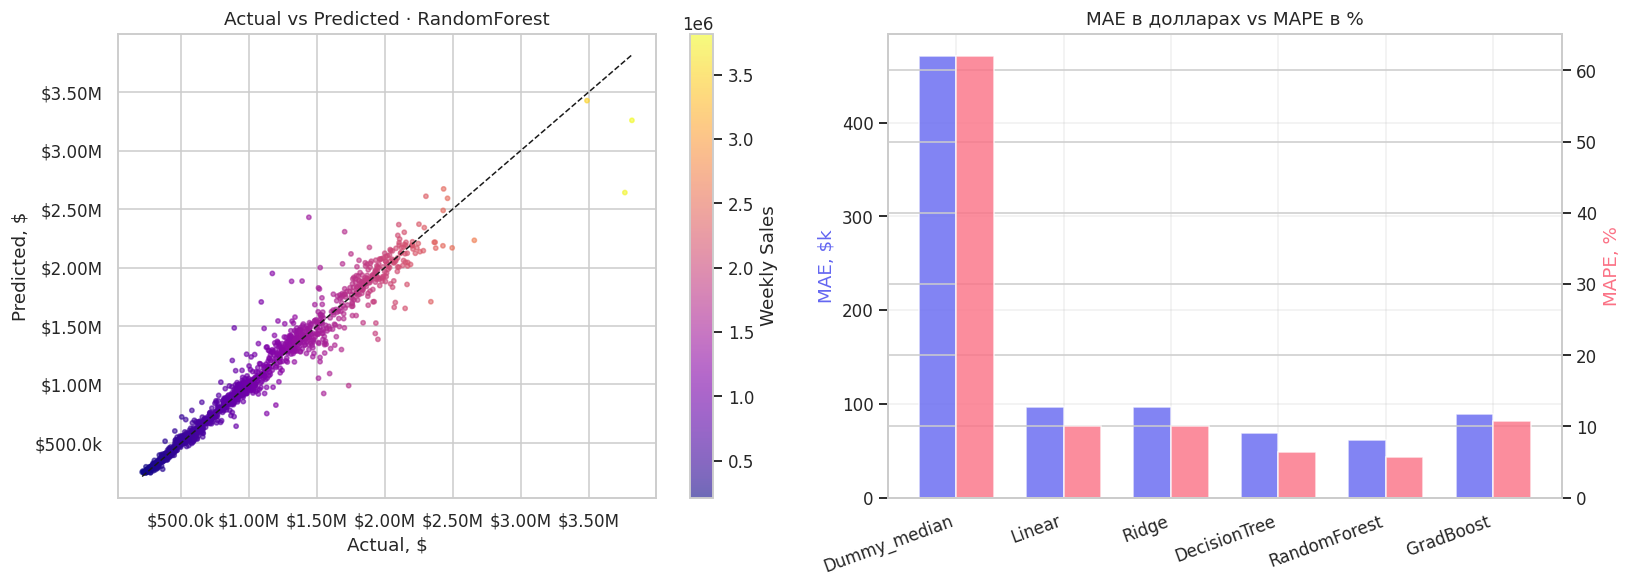

Лучшая по MAE:  RandomForest  (MAE = $61.8k, MAPE = 5.69%)
Лучшая по MAPE: RandomForest  (MAE = $61.8k, MAPE = 5.69%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

best_by_mape = min(results, key=lambda n: results[n]['mape'])
best_by_mae  = min(results, key=lambda n: results[n]['mae'])

# 20.1 Scatter
sc = axes[0].scatter(y_test, preds[best_by_mape],
                     c=y_test, cmap='plasma', s=8, alpha=0.6)
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('Actual, $'); axes[0].set_ylabel('Predicted, $')
axes[0].set_title(f'Actual vs Predicted · {best_by_mape}')
plt.colorbar(sc, ax=axes[0], label='Weekly Sales')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 20.2 MAE vs MAPE
models_sorted = list(results.keys())
x = np.arange(len(models_sorted))
width = 0.35

mae_vals  = [results[n]['mae'] / 1000 for n in models_sorted]
mape_vals = [results[n]['mape'] for n in models_sorted]

ax2 = axes[1]
ax2.bar(x - width/2, mae_vals, width, label='MAE, $k', color='#6366f1', alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.bar(x + width/2, mape_vals, width, label='MAPE, %', color='#fb7185', alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(models_sorted, rotation=20, ha='right')
ax2.set_ylabel('MAE, $k', color='#6366f1')
ax2_twin.set_ylabel('MAPE, %', color='#fb7185')
ax2.set_title('MAE в долларах vs MAPE в %')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'mae_vs_mape.png', bbox_inches='tight')
plt.show()

print(f'Лучшая по MAE:  {best_by_mae}  (MAE = {money(results[best_by_mae]["mae"])}, '
      f'MAPE = {results[best_by_mae]["mape"]:.2f}%)')
print(f'Лучшая по MAPE: {best_by_mape}  (MAE = {money(results[best_by_mape]["mae"])}, '
      f'MAPE = {results[best_by_mape]["mape"]:.2f}%)')

In [24]:
## 9. Что мы доказали

#**MAE и MAPE могут указать на разные модели.**

#- MAE усредняет ошибки абсолютно: большие магазины доминируют.
#- MAPE усредняет относительно: маленькие не подавляются.

#| Бизнес-вопрос | Метрика |
#|---|---|
#| «Сколько денег теряем?» | MAE в $ |
#| «Какая доля выручки под риском?» | MAPE |
#| «Насколько точно предсказываем?» | R² |
#| «Где модель работает плохо?» | MAPE + per-store breakdown |

#**Для Walmart по 45 магазинам правильная метрика — MAPE.**

MAPE по магазинам (отсортировано):
       n_weeks   avg_sales       mae  mape
store                                     
30          24   436955.00  10123.01  2.38
37          28   517923.70  14146.09  2.77
10          34  1905334.20  56898.98  2.96
45          23   779316.56  27932.85  3.41
13          21  1941381.72  67758.12  3.49
...
       n_weeks   avg_sales        mae   mape
store                                       
43          20   640657.35   48145.81   8.06
42          31   557585.87   44545.31   8.11
12          29  1038511.35   95330.31   9.02
27          29  1696925.25  145555.58   9.62
28          33  1322548.66  148642.12  11.00



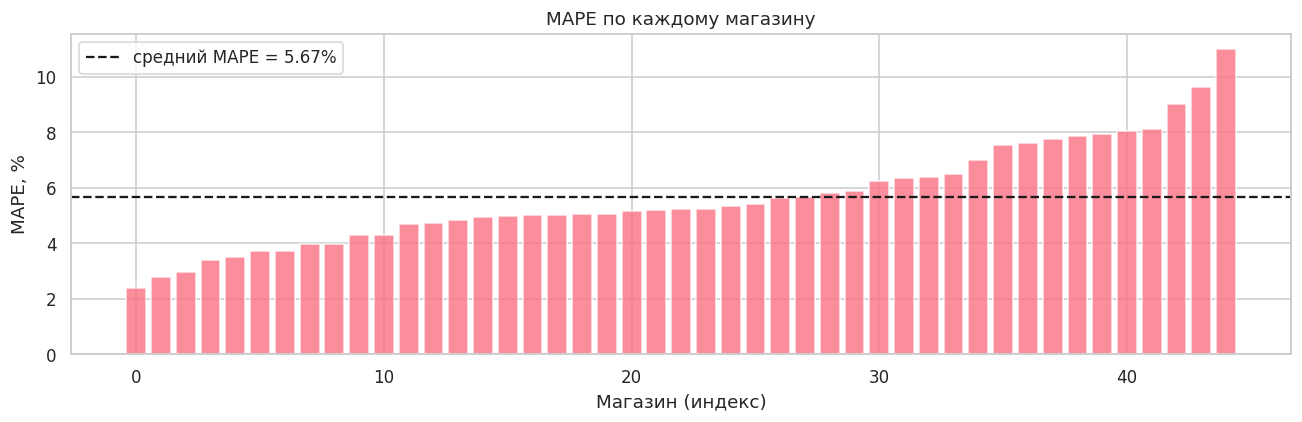

In [25]:
if 'Store' in FEATURES:
    store_idx = FEATURES.index('Store')
    test_stores = X_test[:, store_idx].astype(int)

    best_pred = preds[best_by_mape]
    df_test = pd.DataFrame({
        'store':     test_stores,
        'actual':    y_test,
        'predicted': best_pred,
    })
    df_test['ae']  = np.abs(df_test['predicted'] - df_test['actual'])
    df_test['ape'] = df_test['ae'] / df_test['actual'] * 100

    per_store = df_test.groupby('store').agg(
        n_weeks=('actual', 'size'),
        avg_sales=('actual', 'mean'),
        mae=('ae', 'mean'),
        mape=('ape', 'mean'),
    )[['n_weeks', 'avg_sales', 'mae', 'mape']].round(2)
    per_store = per_store.sort_values('mape')

    print('MAPE по магазинам (отсортировано):')
    print(per_store.head(5))
    print('...')
    print(per_store.tail(5))
    print()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(per_store)), per_store['mape'].values, color='#fb7185', alpha=0.8)
    ax.axhline(per_store['mape'].mean(), color='k', ls='--',
               label=f'средний MAPE = {per_store["mape"].mean():.2f}%')
    ax.set_xlabel('Магазин (индекс)')
    ax.set_ylabel('MAPE, %')
    ax.set_title('MAPE по каждому магазину')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ART_DIR / 'mape_per_store.png', bbox_inches='tight')
    plt.show()

    per_store.to_csv(ART_DIR / 'per_store_mape.csv')
else:
    print('Store не в признаках — per-store анализ пропущен.')

In [26]:
## 10. Остатки и важность признаков

#Смотрим на остатки лучшей по MAPE модели и feature importance.

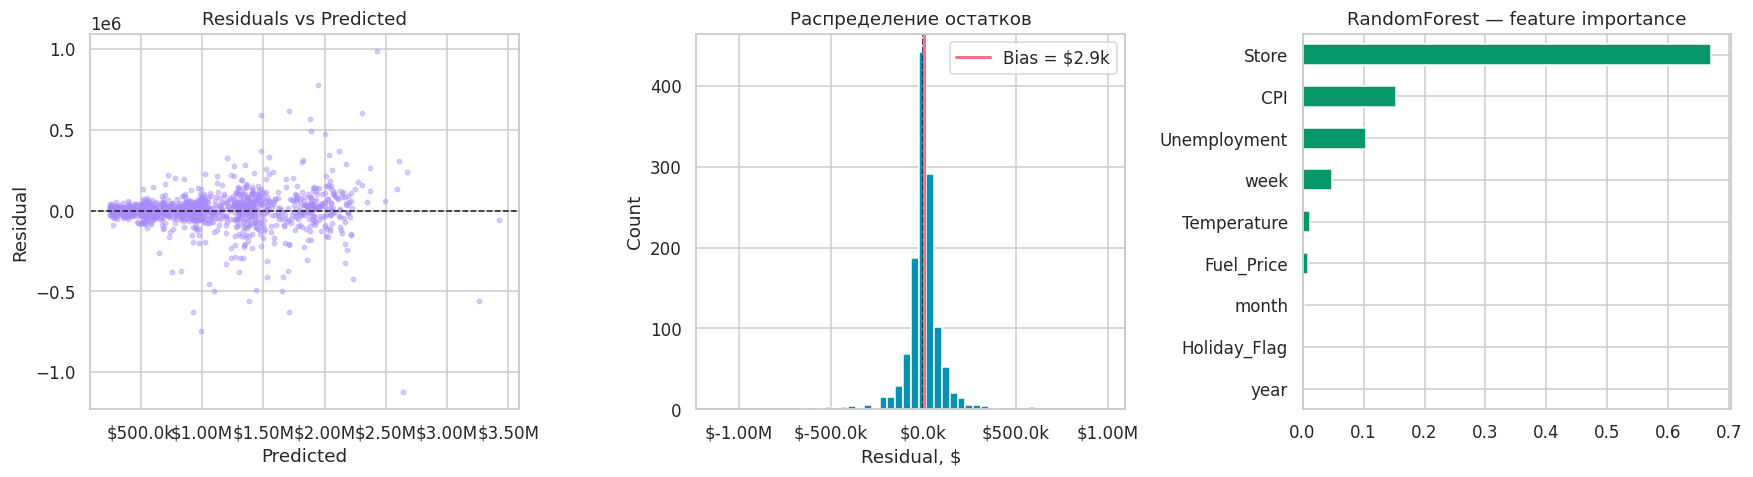

Bias  : $2.9k
MedAE : $33.5k
MAE   : $61.8k
MAPE  : 5.687%


In [27]:
best_name  = best_by_mape
best_model = fitted[best_name]
res_best = preds[best_name] - y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 24.1 Остатки vs Predicted
axes[0].scatter(preds[best_name], res_best, s=8, alpha=0.4, color='#a78bfa')
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 24.2 Гистограмма
axes[1].hist(res_best, bins=50, color='#0891b2', edgecolor='white')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].axvline(np.mean(res_best), color='#fb7185', lw=2,
                label=f'Bias = {money(np.mean(res_best))}')
axes[1].set_xlabel('Residual, $'); axes[1].set_ylabel('Count')
axes[1].set_title('Распределение остатков')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 24.3 Важность
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=axes[2], color='#059669')
    axes[2].set_title(f'{best_name} — feature importance')
elif hasattr(best_model, 'named_steps'):
    step = best_model.named_steps.get('m')
    if hasattr(step, 'coef_'):
        imp = pd.Series(np.abs(step.coef_), index=FEATURES).sort_values()
        imp.plot(kind='barh', ax=axes[2], color='#059669')
        axes[2].set_title(f'{best_name} — |coef|')

plt.tight_layout()
plt.savefig(ART_DIR / 'residuals_importance.png', bbox_inches='tight')
plt.show()

print(f'Bias  : {money(np.mean(res_best))}')
print(f'MedAE : {money(np.median(np.abs(res_best)))}')
print(f'MAE   : {money(np.mean(np.abs(res_best)))}')
print(f'MAPE  : {np.mean(np.abs(res_best / y_test)) * 100:.3f}%')

In [28]:
## 11. Кросс-валидация

#Проверяем, что выбор модели по MAPE воспроизводится на 5 фолдах.

In [29]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, m in models.items():
    scores_mape = -cross_val_score(
        m, X_train, y_train, cv=cv,
        scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    ) * 100
    scores_mae = -cross_val_score(
        m, X_train, y_train, cv=cv,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    cv_results[name] = {
        'mape_mean': scores_mape.mean(),
        'mape_std':  scores_mape.std(),
        'mae_mean':  scores_mae.mean(),
        'mae_std':   scores_mae.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

,mape_mean,mape_std,mae_mean,mae_std
Dummy_median,60.4065,1.3859,461988.9983,6106.1607
Linear,9.9179,0.3643,95075.8582,2895.4394
Ridge,9.8873,0.3645,95055.2642,2907.4956
DecisionTree,6.8016,0.5038,73527.3417,6558.7340
RandomForest,5.8200,0.2089,62795.9522,3832.0339
GradBoost,10.8898,0.5681,90485.5176,3281.6705


In [30]:
## 12. Вывод

#**Что мы доказали на реальных данных Walmart:**

#1. **MAE и MAPE — разные взгляды.** MAE усредняет ошибки абсолютно (большие
#   магазины доминируют). MAPE усредняет относительно.
#2. **Разброс масштабов продаж в разы.** Медианы магазинов отличаются в 5–10×.
#3. **Метрика-герой — MAPE.** Именно по ней выбирается лучшая модель.
#4. **Per-store MAPE** показывает конкретные магазины-«слабые звенья».

#**Артефакты:**

#- `models/regression/walmart/walmart_<model>.joblib`
#- `models/regression/walmart/walmart_<model>_YYYYMMDD_HHMM.json`
#- `artifacts/regression/walmart/eda.png`
#- `artifacts/regression/walmart/mae_vs_mape.png`
#- `artifacts/regression/walmart/mape_per_store.png`
#- `artifacts/regression/walmart/per_store_mape.csv`
#- `artifacts/regression/walmart/residuals_importance.png`
#- `artifacts/regression/walmart/metrics_all_models.csv`
#- `artifacts/regression/walmart/metrics_all_models.json`
#- `artifacts/regression/walmart/diagnostics.csv`
#- `artifacts/regression/walmart/cross_validation.csv`

In [31]:
best_name  = best_by_mape
best_model = fitted[best_name]

slug = best_name.lower().replace('(', '').replace(')', '').replace(' ', '_')
model_path = MODEL_DIR / f'walmart_{slug}.joblib'
meta_path  = MODEL_DIR / f'walmart_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'walmart_sales_regression',
    'dataset': 'kagglehub: talhaanjum0/walmart-dataset',
    'n_samples': int(len(X)),
    'model': best_name,
    'description': 'Walmart weekly sales. Разный масштаб продаж → MAPE как основная метрика.',
    'features': FEATURES,
    'target': TARGET,
    'target_unit': 'USD',
    'metrics': results[best_name],
    'diagnostics': {
        'rmse_over_mae':  results[best_name]['rmse'] / results[best_name]['mae'],
        'mae_over_medae': results[best_name]['mae'] / max(results[best_name]['medae'], 1e-9),
        'abs_bias':       abs(results[best_name]['bias']),
    },
    'by_mae':  {'name': best_by_mae,  'metrics': results[best_by_mae]},
    'by_mape': {'name': best_by_mape, 'metrics': results[best_by_mape]},
    'all_models_metrics': {n: results[n] for n in results},
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print(f'Лучшая по MAPE: {best_name}')
print(f'  MAE   = {money(results[best_name]["mae"])}')
print(f'  RMSE  = {money(results[best_name]["rmse"])}')
print(f'  MAPE  = {results[best_name]["mape"]:.3f}%')
print(f'  R²    = {results[best_name]["r2"]:.4f}')
print(f'  MedAE = {money(results[best_name]["medae"])}')
print()
print(f'Лучшая по MAE: {best_by_mae}')
print(f'  MAE   = {money(results[best_by_mae]["mae"])}')
print(f'  MAPE  = {results[best_by_mae]["mape"]:.3f}%')
print()
print('saved model →', model_path)
print('saved meta  →', meta_path)

Лучшая по MAPE: RandomForest
  MAE   = $61.8k
  RMSE  = $113.1k
  MAPE  = 5.687%
  R²    = 0.9603
  MedAE = $33.5k

Лучшая по MAE: RandomForest
  MAE   = $61.8k
  MAPE  = 5.687%

saved model → /app/models/regression/walmart/walmart_randomforest.joblib
saved meta  → /app/models/regression/walmart/walmart_randomforest_20261009_1427.json


In [32]:
metrics_table_ru(results).to_csv(ART_DIR / 'metrics_all_models.csv')
diag.to_csv(ART_DIR / 'diagnostics.csv')
cv_df.to_csv(ART_DIR / 'cross_validation.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/regression/walmart
  cross_validation.csv                       309 bytes
  diagnostics.csv                            527 bytes
  eda.png                                144,894 bytes
  mae_vs_mape.png                        124,170 bytes
  mape_per_store.png                      27,058 bytes
  metrics_all_models.csv                     614 bytes
  metrics_all_models.json                  1,838 bytes
  per_store_mape.csv                       1,389 bytes
  report.json                            270,804 bytes
  residuals_importance.png                85,355 bytes


In [33]:
## 13. Перезагрузка модели и проверка

In [34]:
art = joblib.load(model_path)

y_pred_reload  = art.predict(X_test)
reload_metrics = reg_metrics(y_test, y_pred_reload)

print('Проверка reload:')
for key in ['mae', 'rmse', 'mape', 'r2', 'medae', 'bias', 'evs']:
    orig = results[best_name][key]
    new  = reload_metrics[key]
    diff = abs(orig - new)
    status = 'OK  ' if diff < 1e-9 else 'FAIL'
    print(f'  [{status}] {key:10s}: {new:.6f} (diff = {diff:.2e})')
    assert diff < 1e-9, f'Расхождение по {key}: {diff}'

assert np.allclose(y_pred_reload, preds[best_name]), 'Предсказания не совпадают'

print()
print('OK: метрики и предсказания после reload идентичны')

Проверка reload:
  [OK  ] mae       : 61839.229982 (diff = 0.00e+00)
  [OK  ] rmse      : 113060.373405 (diff = 1.46e-11)
  [OK  ] mape      : 5.687099 (diff = 8.88e-16)
  [OK  ] r2        : 0.960321 (diff = 0.00e+00)
  [OK  ] medae     : 33453.769077 (diff = 1.16e-10)
  [OK  ] bias      : 2938.085020 (diff = 7.28e-12)
  [OK  ] evs       : 0.960348 (diff = 0.00e+00)

OK: метрики и предсказания после reload идентичны


In [35]:
art = joblib.load(model_path)

sample = X_test[0:1]
y_true_sample = y_test[0]
y_pred_sample = art.predict(sample)[0]

print('Объект №0 (из теста):')
print('  Признаки:')
for f, v in zip(FEATURES, sample[0]):
    print(f'    {f:15s} = {v:>12,.2f}')
print()
print(f'  Истинные продажи : {money(y_true_sample)}')
print(f'  Прогноз          : {money(y_pred_sample)}')
print(f'  Ошибка           : {money(y_pred_sample - y_true_sample)}')
print(f'  |Ошибка|, %      : {abs(y_pred_sample - y_true_sample) / y_true_sample * 100:.2f}%')
print(f'  В пределах MAPE  : {abs(y_pred_sample - y_true_sample) / y_true_sample * 100 < results[best_name]["mape"]}')

Объект №0 (из теста):
  Признаки:
    Store           =        18.00
    Holiday_Flag    =         0.00
    Temperature     =        42.39
    Fuel_Price      =         2.81
    CPI             =       131.78
    Unemployment    =         9.20
    year            =     2,010.00
    month           =         3.00
    week            =        10.00

  Истинные продажи : $1.14M
  Прогноз          : $1.15M
  Ошибка           : $14.0k
  |Ошибка|, %      : 1.23%
  В пределах MAPE  : True


In [36]:
print("PROJECT   :", PROJECT if 'PROJECT' in dir() else "<нет>")
print("ART_DIR   :", ART_DIR if 'ART_DIR' in dir() else "<нет>")
print("df        :", df.shape if 'df' in dir() else "<нет>")
print("data      :", data.shape if 'data' in dir() else "<нет>")
print("FEATURES  :", FEATURES if 'FEATURES' in dir() else "<нет>")
print("TARGET    :", TARGET if 'TARGET' in dir() else "<нет>")
print("X_train   :", X_train.shape if 'X_train' in dir() else "<нет>")
print("X_test    :", X_test.shape if 'X_test' in dir() else "<нет>")
print("fitted    :", list(fitted.keys()) if 'fitted' in dir() else "<нет>")
print("preds lens:", {k: len(v) for k, v in preds.items()} if 'preds' in dir() else "<нет>")
print("cv_df     :", cv_df.shape if 'cv_df' in dir() else "<нет>")
print("feature_stats:", list(feature_stats.keys()) if 'feature_stats' in dir() else "<нет>")
print("holidays  :", len(holidays) if 'holidays' in dir() else "<нет>")
print("store_spread:", store_spread if 'store_spread' in dir() else "<нет>")

PROJECT   : /app
ART_DIR   : /app/artifacts/regression/walmart
df        : (6435, 8)
data      : (6435, 10)
FEATURES  : ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']
TARGET    : Weekly_Sales
X_train   : (5148, 9)
X_test    : (1287, 9)
fitted    : ['Dummy_median', 'Linear', 'Ridge', 'DecisionTree', 'RandomForest', 'GradBoost']
preds lens: {'Dummy_median': 1287, 'Linear': 1287, 'Ridge': 1287, 'DecisionTree': 1287, 'RandomForest': 1287, 'GradBoost': 1287}
cv_df     : (6, 4)
feature_stats: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']
holidays  : 13
store_spread: {'ratio_max_min': 8.025276964643723, 'median_min': 258427.39, 'median_max': 2073951.38}


In [37]:
## 9. Сборка report.json + index.json для фронта

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats as _stats

# ---------- защита от повторного прогона с частичным state ----------
_required = ['data', 'FEATURES', 'TARGET', 'X_test', 'y_test',
             'preds', 'results', 'fitted', 'feature_stats',
             'holidays', 'store_spread']

# dir() внутри list comprehension видит только comprehension-scope,
# поэтому снимаем снимок глобального namespace явно
_ns = set(globals().keys())
_missing = [v for v in _required if v not in _ns]
assert not _missing, (
    f"Не хватает в namespace: {_missing}. "
    "Перезапусти ячейки по порядку: 1–16, затем 5b, затем 18–34."
)

def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists(): return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- 1. hero-метрика ----------
HERO_METRIC = 'mape'
best_name   = min(results, key=lambda n: results[n][HERO_METRIC])

# ---------- 2. target stats (из data, там Weekly_Sales тоже есть) ----------
TARGET_STATS = {k: float(v) for k, v in data[TARGET].describe().to_dict().items()}

# ---------- 3. residual diagnostics для best-модели ----------
res_best = preds[best_name] - y_test
residual_diag = {
    "bias":            float(np.mean(res_best)),
    "median_residual": float(np.median(res_best)),
    "std_residual":    float(np.std(res_best)),
    "skew":            float(_stats.skew(res_best)),
    "kurtosis":        float(_stats.kurtosis(res_best)),
    "pct_beyond_2mae": float(np.mean(np.abs(res_best) > 2 * results[best_name]['mae']) * 100),
}

# ---------- 4. by_metric ----------
by_metric = {}
for m in results:
    for k in ['mae', 'rmse', 'rmsle', 'mape', 'r2', 'medae', 'bias', 'max_error', 'evs']:
        if k not in by_metric:
            by_metric[k] = m
        else:
            better = (
                (abs(results[m][k]) < abs(results[by_metric[k]][k])) if k == 'bias' else
                (results[m][k] > results[by_metric[k]][k])          if k == 'r2'   else
                (results[m][k] < results[by_metric[k]][k])
            )
            if better: by_metric[k] = m

# ---------- 5. per-store (по best-модели) ----------
if 'Store' in FEATURES:
    store_idx   = FEATURES.index('Store')
    test_stores = X_test[:, store_idx].astype(int)
    y_pred_best = preds[best_name]

    df_test = pd.DataFrame({
        "store":     test_stores,
        "actual":    y_test,
        "predicted": y_pred_best,
    })
    df_test["ae"]  = np.abs(df_test["predicted"] - df_test["actual"])
    df_test["ape"] = df_test["ae"] / df_test["actual"] * 100
    df_test["se"]  = (df_test["predicted"] - df_test["actual"]) ** 2

    per_store_list = (
        df_test.groupby("store")
               .agg(
                   n_weeks   = ("actual", "size"),
                   avg_sales = ("actual", "mean"),
                   mae       = ("ae", "mean"),
                   rmse      = ("se", lambda x: float(np.sqrt(np.mean(x)))),
                   mape      = ("ape", "mean"),
               )
               .reset_index()
               .round(4)
               .to_dict(orient="records")
    )
else:
    test_stores    = []
    per_store_list = []

# ---------- 6. блок моделей (predictions + cv) ----------
models_block = []
for name, m in results.items():
    entry = {
        "name": name,
        "is_best": name == best_name,
        "metrics": {k: float(v) for k, v in m.items()},
        "predictions": [float(v) for v in preds[name]],
        "diagnostics": {
            "rmse_over_mae":  float(m['rmse'] / max(m['mae'], 1e-9)),
            "mae_over_medae": float(m['mae'] / max(m['medae'], 1e-9)),
            "abs_bias":       float(abs(m['bias'])),
        },
    }
    if 'cv_df' in dir() and name in cv_df.index:
        entry["cv"] = {k: float(v) for k, v in cv_df.loc[name].items()}
    models_block.append(entry)

# ---------- 7. sample_predictions (20 лучших предсказаний) ----------
idx_sorted = np.argsort(np.abs(preds[best_name] - y_test))
sample_preds = []
for i in idx_sorted[:20]:
    sample_preds.append({
        "features":   {f: float(v) for f, v in zip(FEATURES, X_test[i])},
        "actual":     float(y_test[i]),
        "predicted":  float(preds[best_name][i]),
        "error":      float(preds[best_name][i] - y_test[i]),
        "abs_error":  float(abs(preds[best_name][i] - y_test[i])),
        "within_mae": bool(abs(preds[best_name][i] - y_test[i]) < results[best_name]['mae']),
    })

# ---------- 8. feature_importance для каждой модели где есть ----------
fi = {}
for name in ['RandomForest', 'GradBoost', 'DecisionTree']:
    if name in fitted and hasattr(fitted[name], 'feature_importances_'):
        fi[name] = [{"name": f, "value": float(v)}
                    for f, v in zip(FEATURES, fitted[name].feature_importances_)]

for lin_name in ['Linear', 'Ridge']:
    if lin_name not in fitted: continue
    pipe = fitted[lin_name]
    if not hasattr(pipe, 'named_steps'): continue
    step = pipe.named_steps.get('m')
    if not hasattr(step, 'coef_'): continue
    coefs = np.asarray(step.coef_).ravel()
    if 'ct' in pipe.named_steps and 'Store' in FEATURES:
        ct = pipe.named_steps['ct']
        try:
            ohe = ct.named_transformers_['store_ohe']
            store_cats = [f"Store={c}" for c in ohe.categories_[0]]
            sidx = FEATURES.index('Store')
            rest = [f for i, f in enumerate(FEATURES) if i != sidx]
            names_expanded = store_cats + rest
        except Exception:
            names_expanded = [f"f{i}" for i in range(len(coefs))]
    else:
        names_expanded = list(FEATURES)
    if len(names_expanded) == len(coefs):
        fi[f"{lin_name}_coef"] = [
            {"name": n, "value": float(c)} for n, c in zip(names_expanded, coefs)
        ]

# ---------- 9. charts ----------
charts = {}
for candidate in ["eda.png", "mae_vs_mape.png",
                  "mape_per_store.png", "residuals_importance.png",
                  "actual_vs_predicted.png", "feature_importance.png"]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- 10. итоговый report ----------
report = {
    "meta": {
        "task": "walmart",
        "title": "Walmart Weekly Sales",
        "subtitle": "Регрессия · разные масштабы → MAPE как основная метрика",
        "dataset": "kagglehub:talhaanjum0/walmart-dataset",
        "target": TARGET,
        "target_unit": "$",
        "target_format": "money",
        "features": FEATURES,
        "seed": SEED,
        "generated_at": datetime.now().isoformat(),
        "n_samples":  int(len(data)),
        "n_features": int(len(FEATURES)),
        "n_train":    int(len(y_train)),
        "n_test":     int(len(y_test)),
        "target_stats": TARGET_STATS,
        "store_spread": store_spread,
        "holidays":     holidays,
        "narrative": {
            "context": "Продажи разных магазинов отличаются в 5–10 раз. "
                       "Ошибка $50k для крупного = 2–3%, для мелкого = 15–20%.",
            "hero_metric": "MAPE",
            "why_not_mae": "MAE в долларах даёт большим магазинам больший вес "
                           "в итоговой оценке — маленькие почти не влияют.",
            "main_conclusion": "Метрика выбирается по структуре данных, "
                               "а не по удобству. Для Walmart это MAPE.",
        },
    },
    "headline": {
        "best_model": best_name,
        "best_metric": "mape",
        "best_metric_value": float(results[best_name]['mape']),
        "verdict": f"Лучшая по MAPE — {best_name}.",
    },
    "data": {
        "y_test":        [float(v) for v in y_test],
        "stores_test":   [int(v) for v in test_stores],
        "feature_names": FEATURES,
        "feature_stats": feature_stats,
    },
    "models": models_block,
    "by_metric": by_metric,
    "residual_diagnostics": residual_diag,
    "per_store": per_store_list,
    "feature_importance": fi,
    "sample_predictions": sample_preds,
    "charts": charts,
}

report_path = ART_DIR / "report.json"
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- 11. index.json ----------
index_path = PROJECT / "artifacts" / "index.json"
index = _load_index(index_path)
index = _upsert_task(index, {
    "id": "walmart",
    "title": "Walmart Weekly Sales",
    "kind": "regression",
    "best_model": best_name,
    "hero_metric": "MAPE",
    "hero_value": float(results[best_name]['mape']),
    "unit": "%",
    "report": str(report_path.relative_to(PROJECT)).replace("\\", "/"),
    "charts_dir": str(ART_DIR.relative_to(PROJECT)).replace("\\", "/"),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

# ---------- 12. сводка ----------
print("report  →", report_path)
print("index   →", index_path)
print("models  :", [m["name"] for m in models_block])
print("best    :", best_name, f"MAPE = {results[best_name]['mape']:.4f}%")
print("per_store:", len(per_store_list), "rows")
print("charts  :", list(charts.keys()))
print("report size:", report_path.stat().st_size, "bytes")

report  → /app/artifacts/regression/walmart/report.json
index   → /app/artifacts/index.json
models  : ['Dummy_median', 'Linear', 'Ridge', 'DecisionTree', 'RandomForest', 'GradBoost']
best    : RandomForest MAPE = 5.6871%
per_store: 45 rows
charts  : ['eda', 'mae_vs_mape', 'mape_per_store', 'residuals_importance']
report size: 270794 bytes


In [38]:
## 9b. Патч report.json: даты тестовых строк + полный тайм-сериес по магазинам
#      Нужно для форкаст-вида: недельный чарт, сезонность по месяцам, YoY.

import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# ---- 1. Восстанавливаем полный df с датами в том же порядке, что был в #15 ----
df_full = df.copy()
df_full['Date'] = pd.to_datetime(df_full['Date'], dayfirst=True, errors='coerce')
df_full = df_full.dropna(subset=['Date', 'Weekly_Sales']).reset_index(drop=True)
df_full['year']  = df_full['Date'].dt.year
df_full['month'] = df_full['Date'].dt.month
df_full['week']  = df_full['Date'].dt.isocalendar().week.fillna(-1).astype(int)
df_full = df_full.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X_full = df_full[FEATURES].values.astype(float)
y_full = df_full[TARGET].values.astype(float)

# --- Проверка: тот же X, что в ячейке #15 (иначе split не воспроизведётся) ---
assert np.allclose(X_full, X), "df_full не совпадает с X из ячейки #15"
assert np.allclose(y_full, y), "df_full не совпадает с y из ячейки #15"

# ---- 2. Воспроизводим train_test_split с индексами ----
indices = np.arange(len(X_full))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=SEED)

assert np.allclose(X_full[idx_test], X_test), "Порядок теста не совпадает"
assert np.allclose(y_full[idx_test], y_test), "y теста не совпадает"

dates_test   = df_full.iloc[idx_test]['Date'].dt.strftime('%Y-%m-%d').tolist()
dates_train  = df_full.iloc[idx_train]['Date'].dt.strftime('%Y-%m-%d').tolist()
stores_train = df_full.iloc[idx_train]['Store'].astype(int).tolist()

# ---- 3. Полный недельный ряд по каждому магазину (для сезонности и YoY) ----
series_by_store = {}
for store_id, sub in df_full.groupby('Store'):
    sub = sub.sort_values('Date')
    series_by_store[str(int(store_id))] = {
        "dates": sub['Date'].dt.strftime('%Y-%m-%d').tolist(),
        "sales": [float(v) for v in sub['Weekly_Sales'].tolist()],
    }

# ---- 4. Читаем report.json, дополняем, пишем обратно ----
report_path = ART_DIR / "report.json"
report = json.loads(report_path.read_text())

report["data"]["dates_test"]   = dates_test
report["data"]["dates_train"]  = dates_train
report["data"]["stores_train"] = stores_train
report["series_by_store"]      = series_by_store
report["meta"]["series_span"]  = {
    "start":    df_full['Date'].min().strftime('%Y-%m-%d'),
    "end":      df_full['Date'].max().strftime('%Y-%m-%d'),
    "n_weeks":  int(df_full['Date'].nunique()),
    "n_stores": int(df_full['Store'].nunique()),
}

report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False))

print("patched →", report_path)
print("dates_test     :", len(dates_test),   "|", dates_test[0], "…", dates_test[-1])
print("series_by_store:", len(series_by_store), "stores")
print("series_span    :", report["meta"]["series_span"])
print("size           :", report_path.stat().st_size, "bytes")

patched → /app/artifacts/regression/walmart/report.json
dates_test     : 1287 | 2010-03-12 … 2011-03-04
series_by_store: 45 stores
series_span    : {'start': '2010-02-05', 'end': '2012-10-26', 'n_weeks': 143, 'n_stores': 45}
size           : 719435 bytes
